# **Clustering Countries by CO₂ Emissions and Economic Indicators**
**Course**: PTAI - Programming Techniques in AI  
**Project Title**: Emission Data Analysis and Unsupervised Clustering of Nations  
**Submitted by**: *Asma, Batool, and Rofidah*  


---

## **Project Description**

This project aims to explore and analyze global CO₂ emissions in relation to economic factors using unsupervised machine learning techniques. We preprocess historical emissions data and GDP statistics to identify patterns and similarities across countries.

Key steps include:
- Cleaning and transforming emissions and GDP datasets  
- Handling missing and zero values  
- Performing feature engineering  
- Applying clustering algorithms (KMeans, DBSCAN, GMM)  
- Interpreting cluster profiles to understand emission behaviors

The goal is to group countries based on both **environmental** and **economic indicators**, revealing hidden structures in emission trends and helping inform targeted climate policies.

---


#**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

#**1) Data Loading**

### **Loading CO₂ Emissions Dataset**

We begin by importing the historical CO₂ emissions dataset, which includes national-level carbon emissions from 1751 to 2022.
This dataset forms the environmental foundation of the analysis and will later be merged with economic data such as GDP.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Data loading

file_path = "/content/drive/MyDrive/MSAI_Pro_L1/PTAI_Project/nation.1751_2022.xlsx"

OrigData = pd.read_excel(file_path)
OrigData.head()

,Nation,Nation ID,Year,Emissions from fossil fuels and cement production (thousand metric tons of C),Emissions from solid fuel consumption,Emissions from liquid fuel consumption,Emissions from gas fuel consumption,Emissions from cement production,Emissions from gas flaring,Emissions per capita (metric tons of carbon),Emissions from bunker fuels (not included in the totals),Emissions from aviation bunker fuels (subset of bunker emissions)
0,Afghanistan,4,1949,4,4.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN
1,Afghanistan,4,1950,23,6.0,18.0,0.0,0.0,NaN,0.003025,0.0,0.0
2,Afghanistan,4,1951,25,7.0,18.0,0.0,0.0,NaN,0.003172,0.0,0.0
3,Afghanistan,4,1952,25,9.0,17.0,0.0,0.0,NaN,0.003206,0.0,0.0
4,Afghanistan,4,1953,29,10.0,18.0,0.0,0.0,NaN,0.003551,0.0,0.0


#**2) EDA**

In [ ]:
# Bsic info about the data

print("Shape:", OrigData.shape)
print("\nColumns:\n", OrigData.columns)

print("\nInfo:")
OrigData.info()

print("\nMissing values per column:")
print(OrigData.isna().sum())


Shape: (19278, 12)

Columns:
 Index(['Nation', 'Nation ID', 'Year',
       'Emissions from fossil fuels and cement production (thousand metric tons of C)',
       'Emissions from solid fuel consumption',
       'Emissions from liquid fuel consumption',
       'Emissions from gas fuel consumption',
       'Emissions from cement production', 'Emissions from gas flaring',
       'Emissions per capita (metric tons of carbon)',
       'Emissions from bunker fuels (not included in the totals)',
       'Emissions from aviation bunker fuels (subset of bunker emissions)'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 12 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   Nation                                                                

### **Cleaning and Preprocessing Emissions Data**

This step involves:
- Filtering out irrelevant years
- Dropping null values
- Renaming columns for consistency

We prepare the emissions dataset for imputation and analysis.


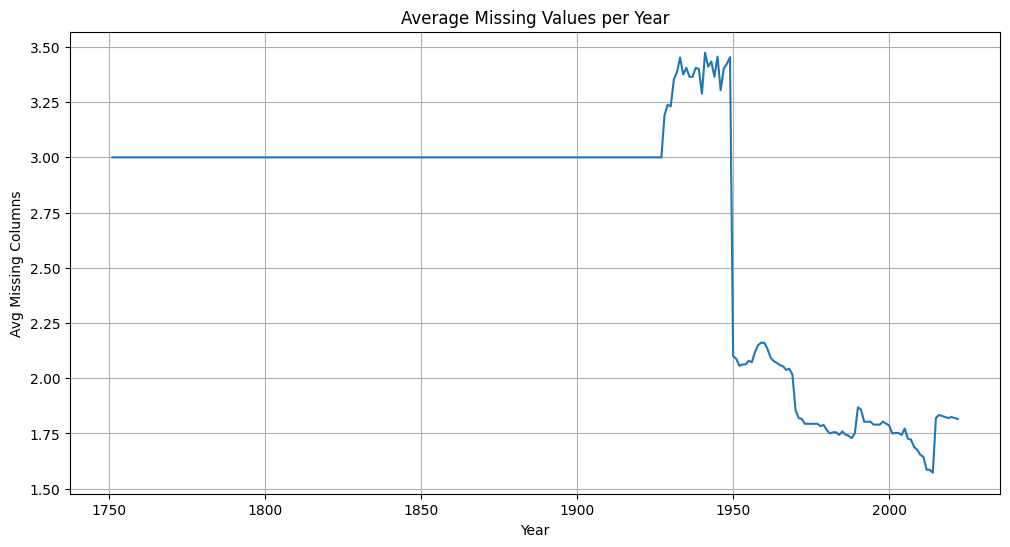

In [ ]:
# Count mising value per year

missing_by_year = OrigData.isna().sum(axis=1)  # number of missing columns per row
OrigData["MissingCount"] = missing_by_year

missing_per_year = OrigData.groupby("Year")["MissingCount"].mean()

plt.figure(figsize=(12,6))
plt.plot(missing_per_year.index, missing_per_year.values)
plt.title("Average Missing Values per Year")
plt.xlabel("Year")
plt.ylabel("Avg Missing Columns")
plt.grid(True)
plt.show()

/tmp/ipython-input-3812300321.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completeness = OrigData.groupby("Year").apply(lambda x: x.notna().mean() * 100)


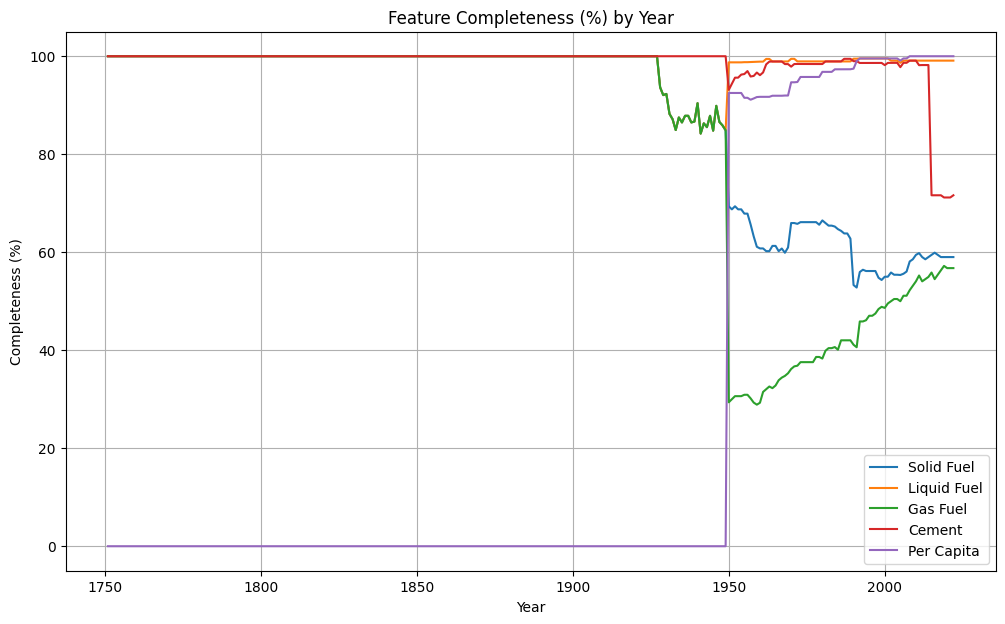

In [ ]:
# % Completness per year

completeness = OrigData.groupby("Year").apply(lambda x: x.notna().mean() * 100)

plt.figure(figsize=(12,7))
plt.plot(completeness.index, completeness["Emissions from solid fuel consumption"], label="Solid Fuel")
plt.plot(completeness.index, completeness["Emissions from liquid fuel consumption"], label="Liquid Fuel")
plt.plot(completeness.index, completeness["Emissions from gas fuel consumption"], label="Gas Fuel")
plt.plot(completeness.index, completeness["Emissions from cement production"], label="Cement")
plt.plot(completeness.index, completeness["Emissions per capita (metric tons of carbon)"], label="Per Capita")
plt.legend()
plt.title("Feature Completeness (%) by Year")
plt.xlabel("Year")
plt.ylabel("Completeness (%)")
plt.grid(True)
plt.show()

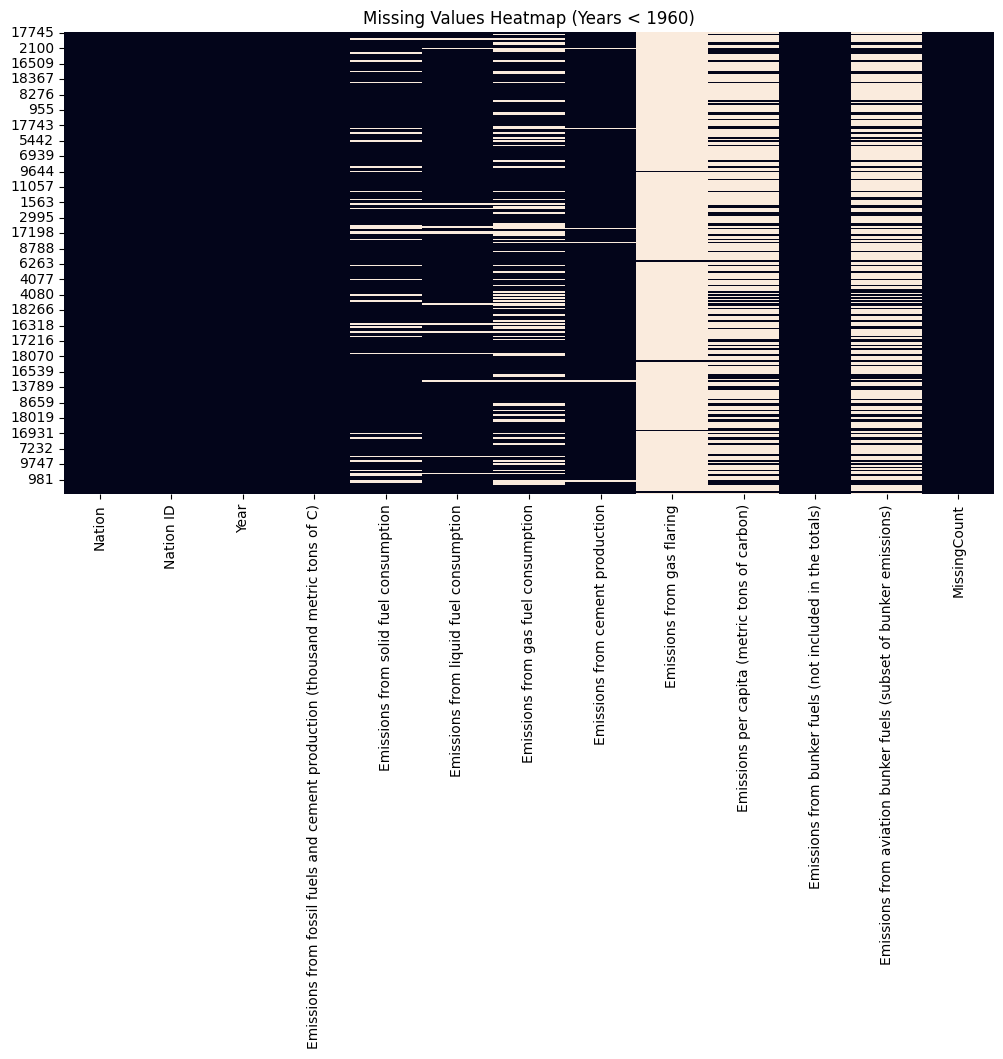

In [ ]:
sample = OrigData[OrigData["Year"] < 1960].sample(300)  # sample to avoid large plot

plt.figure(figsize=(12,6))
sns.heatmap(sample.isna(), cbar=False)
plt.title("Missing Values Heatmap (Years < 1960)")
plt.show()

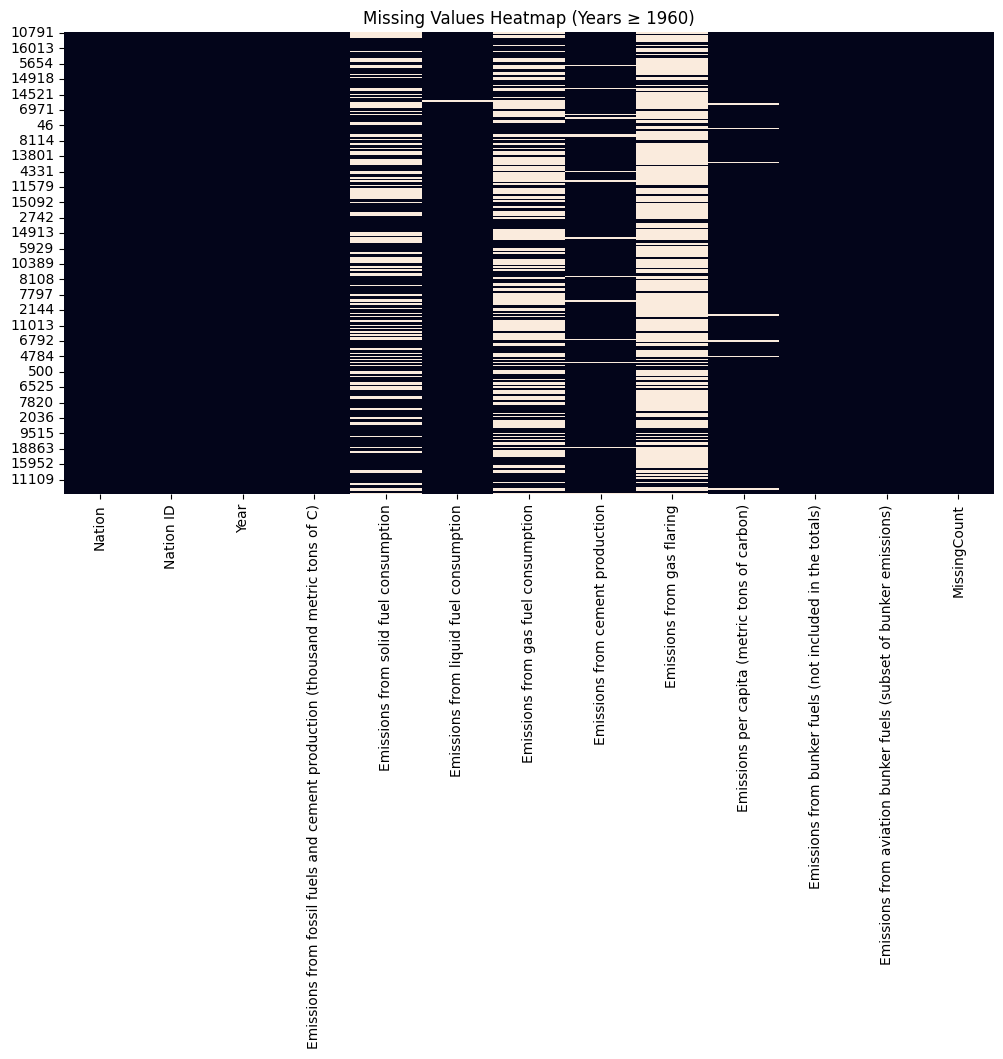

In [ ]:
sample2 = OrigData[OrigData["Year"] >= 1960].sample(300)

plt.figure(figsize=(12,6))
sns.heatmap(sample2.isna(), cbar=False)
plt.title("Missing Values Heatmap (Years ≥ 1960)")
plt.show()

> **Note: (Data Filtering Justification)**  
> Based on the above visualizations, we observe that CO₂ emissions data prior to 1960 exhibits a high level of missing values and inconsistent feature completeness. This justifies filtering the dataset to include only records from 1960 onward, ensuring a more robust and comparable analysis across countries.


### **Reporting Coverage Over Time**

This plot shows the number of countries reporting CO₂ emissions each year.
A gradual increase, especially after 1950, reflects broader international participation in emissions monitoring.
The sharp jump around the 1960s validates our decision to focus on data post-1960 due to improved global coverage.

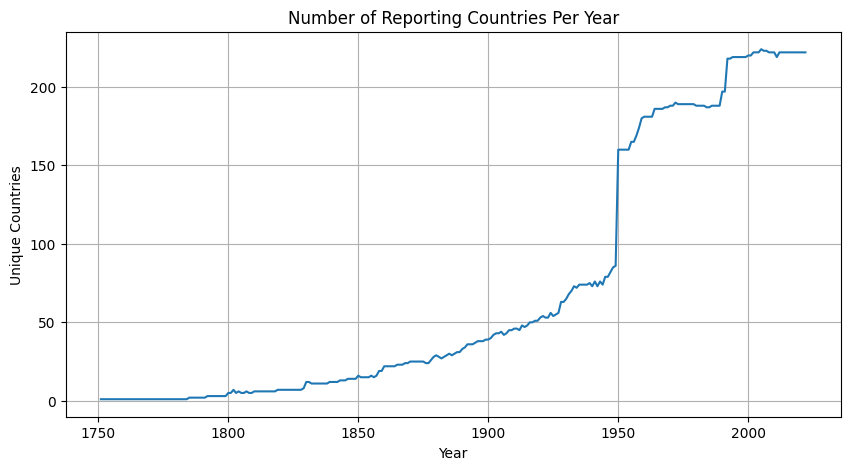

In [ ]:
countries_per_year = OrigData.groupby("Year")["Nation"].nunique()

plt.figure(figsize=(10,5))
plt.plot(countries_per_year.index, countries_per_year.values)
plt.title("Number of Reporting Countries Per Year")
plt.xlabel("Year")
plt.ylabel("Unique Countries")
plt.grid(True)
plt.show()

### **Frequency of Zero Values in Emission Features**

Some countries reported zero emissions for specific fuel types in certain years, either due to non-use or missing documentation.
This chart tracks the number of zero values per year for major emission sources.
It further illustrates data sparsity in early decades and supports our filtering strategy for robust analysis.

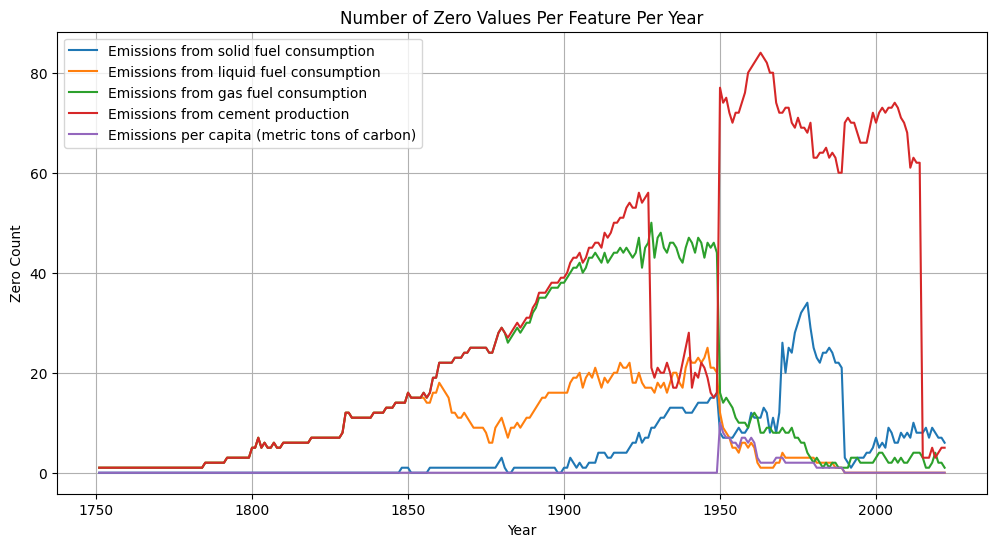

In [ ]:
features = [
    'Emissions from solid fuel consumption',
    'Emissions from liquid fuel consumption',
    'Emissions from gas fuel consumption',
    'Emissions from cement production',
    'Emissions per capita (metric tons of carbon)'
]

zero_counts = OrigData.groupby("Year")[features].apply(lambda df: (df == 0).sum())

plt.figure(figsize=(12,6))
for col in features:
    plt.plot(zero_counts.index, zero_counts[col], label=col)

plt.title("Number of Zero Values Per Feature Per Year")
plt.xlabel("Year")
plt.ylabel("Zero Count")
plt.legend()
plt.grid(True)
plt.show()

###**Filtering Dataset by Year**

Based on completeness and coverage analysis, we filter the dataset to retain only records from 1960 onwards.

In [ ]:
# Copy the original data & filtering the year

df = OrigData.copy()

# Keep only data from 1960 onwards
df = df[df["Year"] >= 1960].reset_index(drop=True)

print("New shape after year filtering:", df.shape)

New shape after year filtering: (12856, 13)


### **Post-Filtering Missing Value Summary**
After filtering, we reassess missing values across columns.
This step confirms which emission features still require imputation and guides the preprocessing pipeline.

In [ ]:
# Check missing values after filtering
df.isna().sum()

,0
Nation,0
Nation ID,0
Year,0
Emissions from fossil fuels and cement production (thousand metric tons of C),0
Emissions from solid fuel consumption,5139
Emissions from liquid fuel consumption,111
Emissions from gas fuel consumption,7064
Emissions from cement production,665
Emissions from gas flaring,9969
Emissions per capita (metric tons of carbon),314


### **Renaming Columns for Clarity and Consistency**

In [ ]:
# Rename the cols to clean names
df = df.rename(columns={
    'Emissions from fossil fuels and cement production (thousand metric tons of C)': 'Total',
    'Emissions from solid fuel consumption': 'Solid_fuel',
    'Emissions from liquid fuel consumption': 'Liquid_fuel',
    'Emissions from gas fuel consumption': 'Gas_fuel',
    'Emissions from cement production': 'Cement',
    'Emissions from gas flaring': 'Gas_flaring',
    'Emissions per capita (metric tons of carbon)': 'Per_capita',
    'Emissions from bunker fuels (not included in the totals)': 'Bunker_fuel',
    'Emissions from aviation bunker fuels (subset of bunker emissions)': 'Aviation_fuel'
})

df.head()

,Nation,Nation ID,Year,Total,Solid_fuel,Liquid_fuel,Gas_fuel,Cement,Gas_flaring,Per_capita,Bunker_fuel,Aviation_fuel,MissingCount
0,Afghanistan,4,1960,113,35.0,74.0,0.0,5.0,NaN,0.012676,0.0,0.0,1
1,Afghanistan,4,1961,134,48.0,80.0,0.0,6.0,NaN,0.014709,0.0,0.0,1
2,Afghanistan,4,1962,188,81.0,99.0,0.0,8.0,NaN,0.020189,0.0,0.0,1
3,Afghanistan,4,1963,193,72.0,107.0,0.0,14.0,NaN,0.020296,0.0,0.0,1
4,Afghanistan,4,1964,229,82.0,130.0,0.0,17.0,NaN,0.023550,0.0,0.0,1


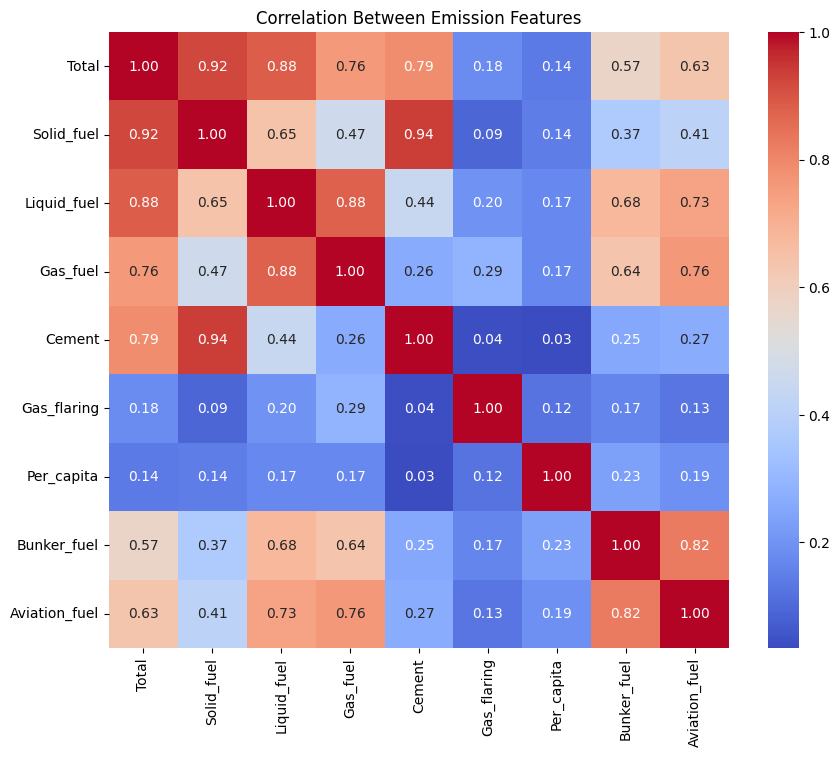

In [ ]:
features = [
    'Total',
    'Solid_fuel',
    'Liquid_fuel',
    'Gas_fuel',
    'Cement',
    'Gas_flaring',
    'Per_capita',
    'Bunker_fuel',
    'Aviation_fuel'
]

plt.figure(figsize=(10,8))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Emission Features")
plt.show()

The figure shows that:

- Countries with high coal emissions also have high cement emissions (industrialization)

- Countries with high oil use have high gas emissions (energy mix)

- Internationally active countries (trade & travel) have high aviation & bunker fuel emissions

This proves that the dataset has structure, and KNN can exploit this structure for handling missing values

##**Handling missing values**
Comparing between these 2 methods
- Method 1: KNN
- Method 2: Mean value

###Merhod 1: KNN

In [ ]:
# Handling missing values
# the case is MAR (mising at random) - The missingness depends on other variables, not the emission value itself - Suitable for KNN or Mean/Median imputation
# e.g. a country has cement emissions missing because it does not report it, but reporting depends on country characteristics, not the value itself
num_cols = [
    'Total', 'Solid_fuel', 'Liquid_fuel', 'Gas_fuel',
    'Cement', 'Gas_flaring', 'Per_capita',
    'Bunker_fuel', 'Aviation_fuel'
]

# method 1 - KNN
imputer = KNNImputer(n_neighbors=5, weights='distance')

df_imputed = df.copy()

df_imputed[num_cols] = imputer.fit_transform(df_imputed[num_cols])

df_imputed[num_cols].isna().sum()

,0
Total,0
Solid_fuel,0
Liquid_fuel,0
Gas_fuel,0
Cement,0
Gas_flaring,0
Per_capita,0
Bunker_fuel,0
Aviation_fuel,0


<Figure size 1200x600 with 0 Axes>

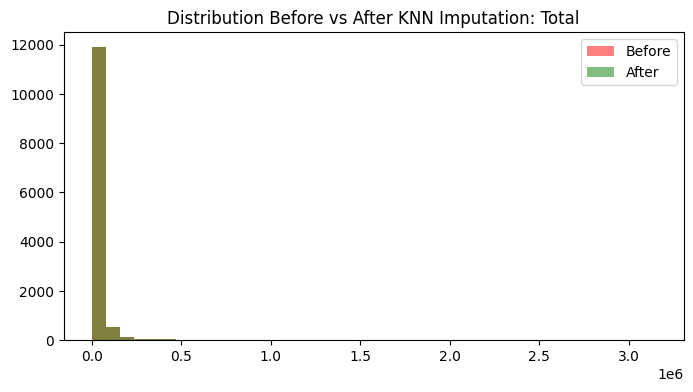

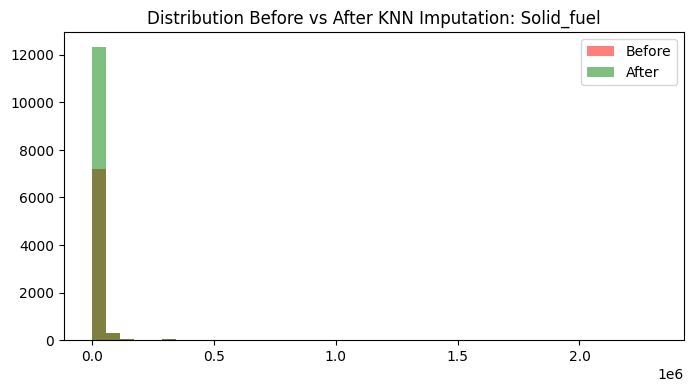

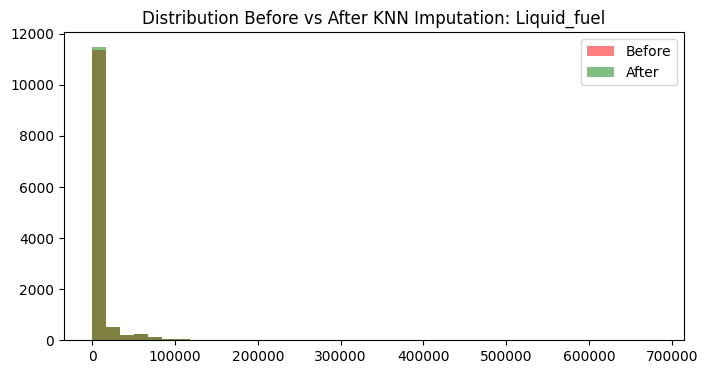

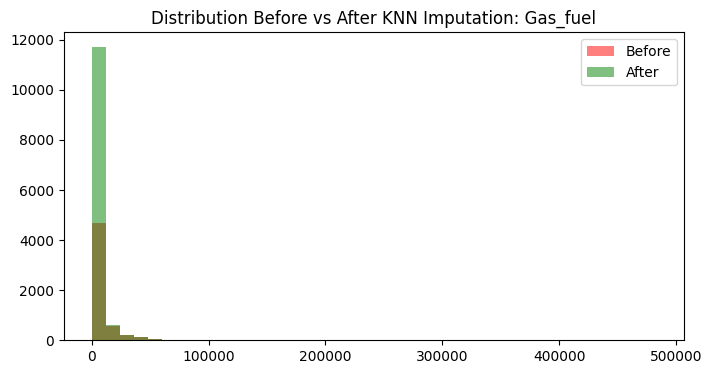

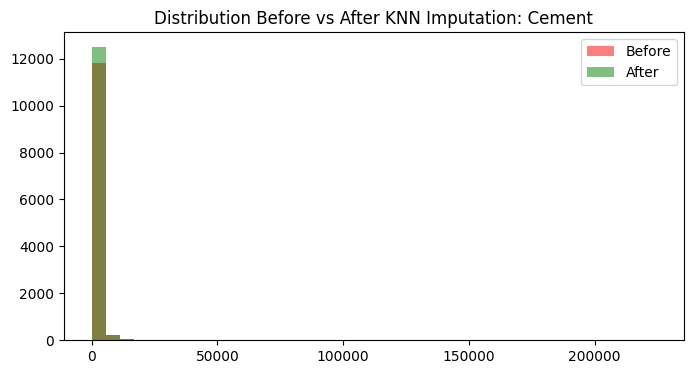

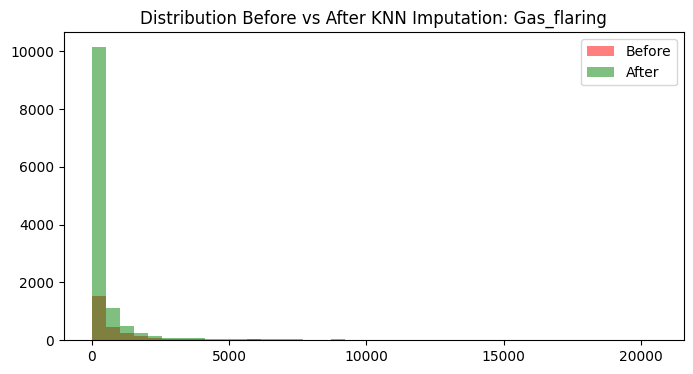

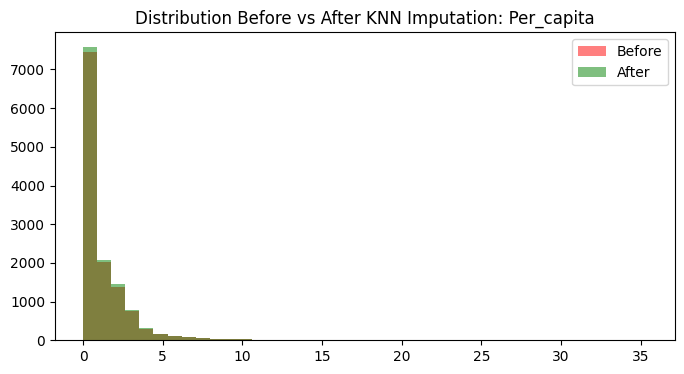

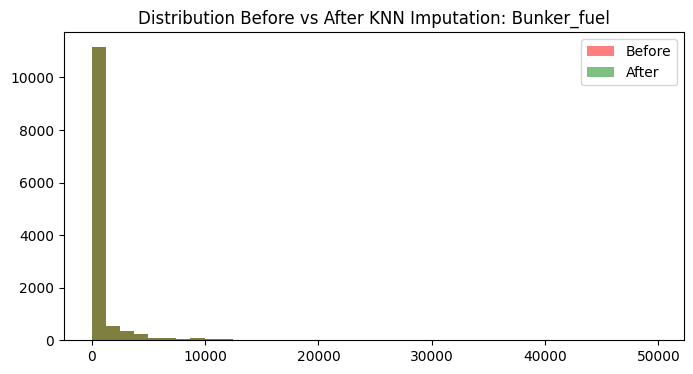

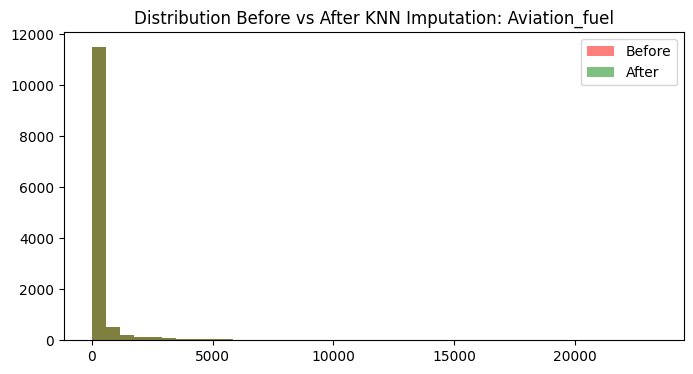

In [ ]:
plt.figure(figsize=(12,6))

for col in num_cols:
    plt.figure(figsize=(8,4))
    plt.hist(df[col], bins=40, alpha=0.5, label='Before', color='red')
    plt.hist(df_imputed[col], bins=40, alpha=0.5, label='After', color='green')
    plt.title(f"Distribution Before vs After KNN Imputation: {col}")
    plt.legend()
    plt.show()

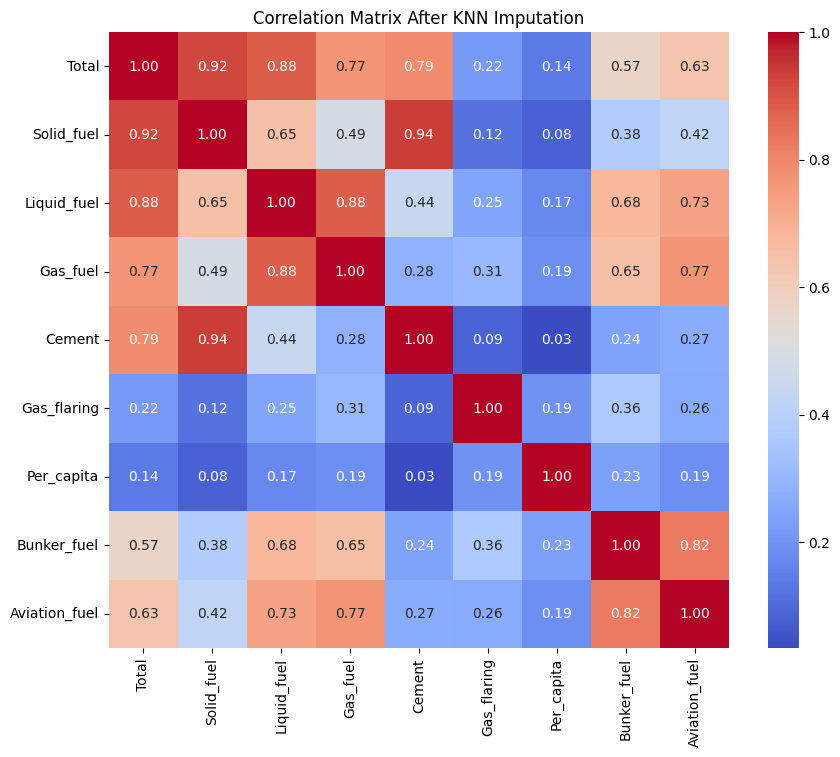

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_imputed[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix After KNN Imputation")
plt.show()


In [ ]:
missing_rows = df[df[num_cols].isna().any(axis=1)].head()

print("Before Imputation:")
display(missing_rows[num_cols])

print("After Imputation:")
display(df_imputed.loc[missing_rows.index, num_cols])


Before Imputation:


,Total,Solid_fuel,Liquid_fuel,Gas_fuel,Cement,Gas_flaring,Per_capita,Bunker_fuel,Aviation_fuel
0,113,35.0,74.0,0.0,5.0,NaN,0.012676,0.0,0.0
1,134,48.0,80.0,0.0,6.0,NaN,0.014709,0.0,0.0
2,188,81.0,99.0,0.0,8.0,NaN,0.020189,0.0,0.0
3,193,72.0,107.0,0.0,14.0,NaN,0.020296,0.0,0.0
4,229,82.0,130.0,0.0,17.0,NaN,0.023550,0.0,0.0


After Imputation:


,Total,Solid_fuel,Liquid_fuel,Gas_fuel,Cement,Gas_flaring,Per_capita,Bunker_fuel,Aviation_fuel
0,113.0,35.0,74.0,0.0,5.0,40.596408,0.012676,0.0,0.0
1,134.0,48.0,80.0,0.0,6.0,52.122265,0.014709,0.0,0.0
2,188.0,81.0,99.0,0.0,8.0,47.252641,0.020189,0.0,0.0
3,193.0,72.0,107.0,0.0,14.0,39.261331,0.020296,0.0,0.0
4,229.0,82.0,130.0,0.0,17.0,28.005542,0.023550,0.0,0.0


###Method 2: Mean

In [ ]:

# Method 2 - Mean
df_mean = df.copy()

# Apply mean imputation to all numeric columns
df_mean_imputed = df_mean.fillna(df_mean.mean(numeric_only=True))

print("Missing values after Mean Imputation:")
print(df_mean_imputed.isna().sum())

Missing values after Mean Imputation:
Nation           0
Nation ID        0
Year             0
Total            0
Solid_fuel       0
Liquid_fuel      0
Gas_fuel         0
Cement           0
Gas_flaring      0
Per_capita       0
Bunker_fuel      0
Aviation_fuel    0
MissingCount     0
dtype: int64


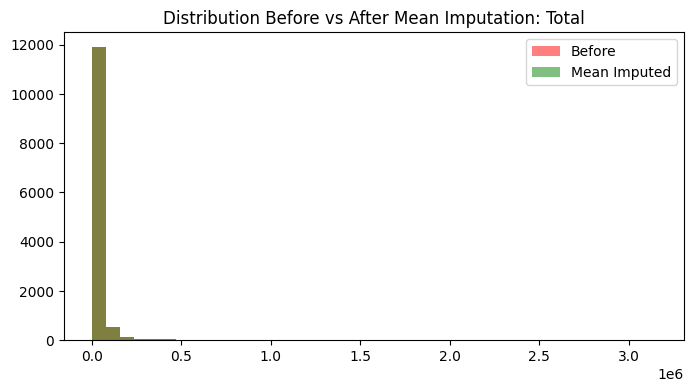

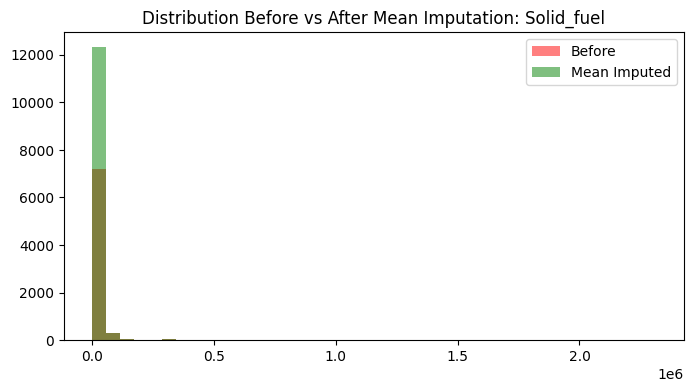

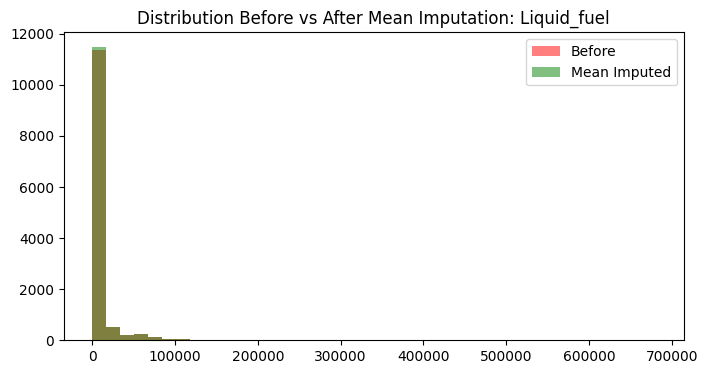

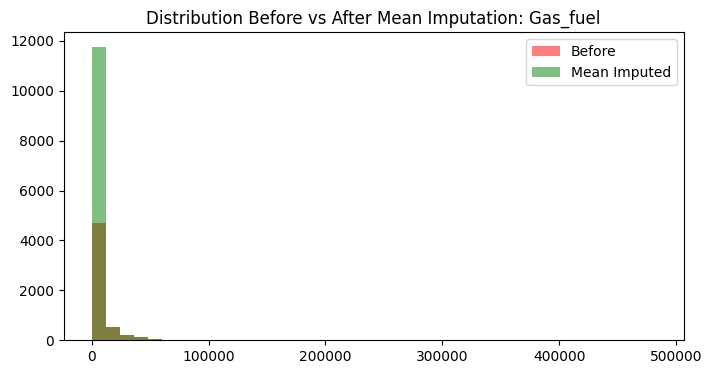

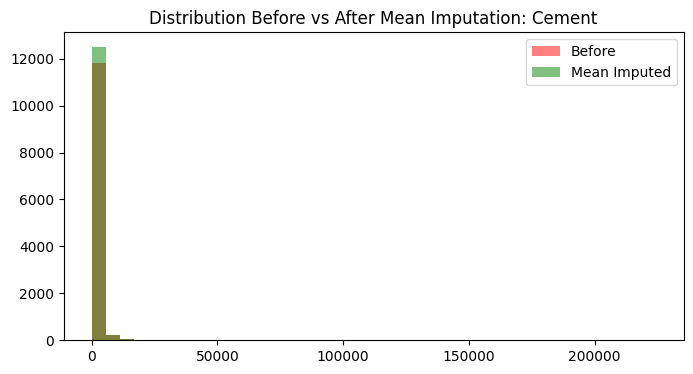

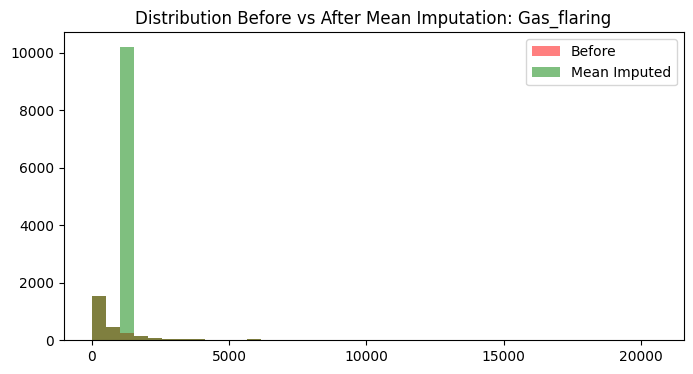

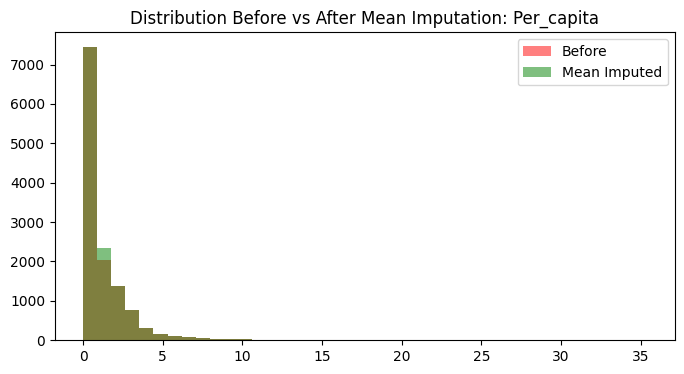

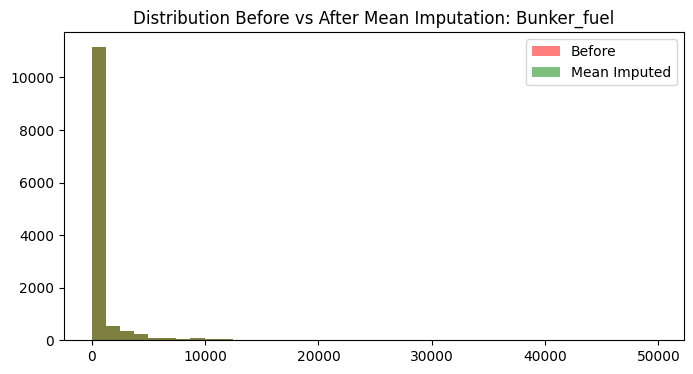

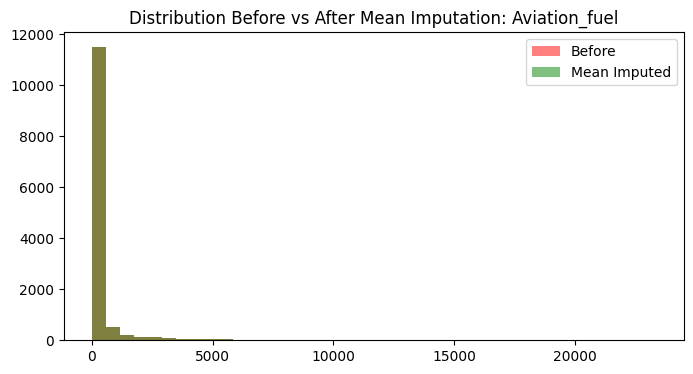

In [ ]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    plt.hist(df[col], bins=40, alpha=0.5, label='Before', color='red')
    plt.hist(df_mean_imputed[col], bins=40, alpha=0.5, label='Mean Imputed', color='green')
    plt.title(f"Distribution Before vs After Mean Imputation: {col}")
    plt.legend()
    plt.show()

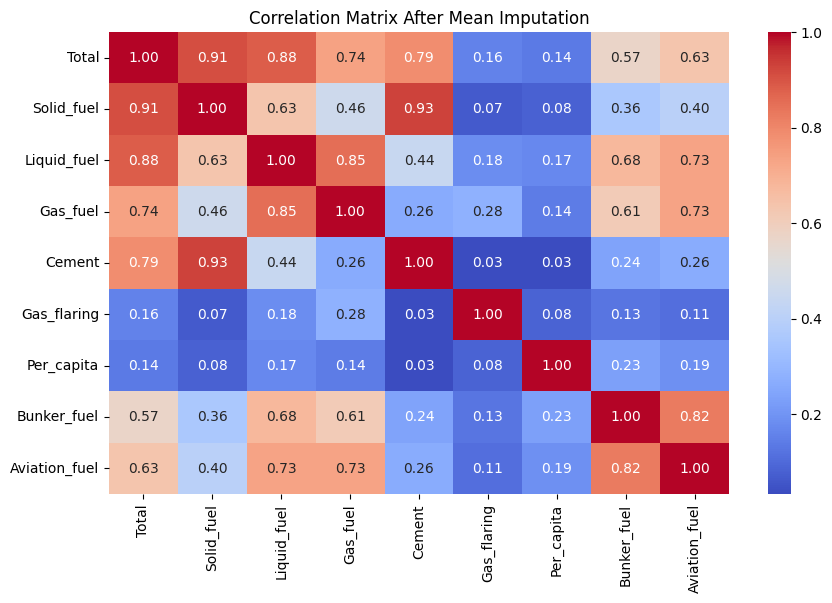

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df_mean_imputed[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix After Mean Imputation")
plt.show()

> **Imputation Strategy Evaluation:**
>
> The histograms above demonstrate that mean imputation distorts the distribution of several features (e.g., `Aviation_fuel`), resulting in artificial peaks around the mean. This behavior may reduce the quality of downstream analysis.
>
> In contrast, K-Nearest Neighbors (KNN) imputation preserves the shape and spread of each variable by estimating missing values based on structurally similar records. This is further supported by the correlation matrix: mean imputation weakens inter-variable relationships, whereas KNN retains the original feature correlations more accurately.
>
> Given the importance of maintaining real-world feature relationships in clustering and dimensionality reduction, **KNN imputation is selected** as the preferred method in this study.

#**3) Feature Engineering**

### **Country-Level Feature Engineering**

To enable clustering at the country level, we aggregate emissions and related metrics over time.
This step transforms longitudinal (yearly) data into a fixed-format, country-level dataset using the following features:

- **Average and maximum values** of total CO₂ emissions and per capita emissions.
- **Fuel composition features** (mean CO₂ emissions from solid, liquid, gas, cement, etc.).
- **Growth rate**, calculated using the log difference of total emissions over time.
- **Fuel ratios** representing the relative dominance of fuel types (e.g., solid vs. liquid).

This set of engineered features enables multidimensional clustering of countries based on both intensity and structure of emissions.

In [ ]:
df_work = df_imputed

country_features = df_work.groupby('Nation').agg({

    # Emission magnitude
    'Total': ['mean', 'std', 'max'],

    # Per-capita behavior
    'Per_capita': ['mean', 'max'],

    # Fuel composition
    'Solid_fuel': 'mean',
    'Liquid_fuel': 'mean',
    'Gas_fuel': 'mean',
    'Cement': 'mean',
    'Gas_flaring': 'mean',

    # Transport-related
    'Bunker_fuel': 'mean',
    'Aviation_fuel': 'mean'

}).reset_index()

country_features.columns = [
    'Nation',
    'total_mean', 'total_std', 'total_max',
    'percapita_mean', 'percapita_max',
    'solid_mean', 'liquid_mean', 'gas_mean',
    'cement_mean', 'gas_flaring_mean',
    'bunker_mean', 'aviation_mean'
]

def growth_rate(group):
    x = np.arange(len(group))
    y = group['Total'].values
    return np.polyfit(x, y, 1)[0] if len(y) > 1 else 0

growth = df_work.groupby('Nation').apply(growth_rate)
country_features['growth_rate'] = country_features['Nation'].map(growth)

fuel_sum = (
    country_features['solid_mean'] +
    country_features['liquid_mean'] +
    country_features['gas_mean']
)

country_features['solid_ratio']  = country_features['solid_mean']  / fuel_sum
country_features['liquid_ratio'] = country_features['liquid_mean'] / fuel_sum
country_features['gas_ratio']    = country_features['gas_mean']    / fuel_sum

country_features.head()
country_features.isna().sum()


/tmp/ipython-input-3071124810.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  growth = df_work.groupby('Nation').apply(growth_rate)


,0
Nation,0
total_mean,0
total_std,1
total_max,0
percapita_mean,0
percapita_max,0
solid_mean,0
liquid_mean,0
gas_mean,0
cement_mean,0


In [ ]:
country_features.head(10)


,Nation,total_mean,total_std,total_max,percapita_mean,percapita_max,solid_mean,liquid_mean,gas_mean,cement_mean,gas_flaring_mean,bunker_mean,aviation_mean,growth_rate,solid_ratio,liquid_ratio,gas_ratio
0,Afghanistan,951.126984,912.485431,3114.0,0.045248,0.108614,236.444444,589.793651,87.619048,11.476190,136.268872,17.111111,17.111111,37.611655,0.258732,0.645389,0.095878
1,Albania,1212.365079,507.581880,2450.0,0.443844,0.779505,291.634921,759.317460,69.809524,91.587302,242.316873,11.222222,7.444444,2.615543,0.260211,0.677501,0.062288
2,Algeria,21109.730159,13372.919776,48974.0,0.728131,1.085345,416.317460,7335.571429,9781.929359,982.984127,2597.859309,423.095238,198.841270,712.063364,0.023744,0.418367,0.557889
3,American Samoa,123.060606,10.419151,135.0,2.313782,2.841993,0.730881,123.060606,0.882283,0.057587,0.386128,23.636364,14.909091,-0.862634,0.005862,0.987061,0.007077
4,Andorra,130.757576,14.796601,158.0,1.855581,2.194145,0.000000,130.454545,1.407209,0.011225,2.172074,0.000000,0.000000,0.179144,0.000000,0.989328,0.010672
5,Angola,3078.523810,2891.694106,9244.0,0.178920,0.374390,982.112611,1490.857143,208.144513,123.126984,1256.862497,326.460317,137.126984,135.188892,0.366308,0.556059,0.077634
6,Anguilla,27.272727,9.348371,39.0,2.192302,2.744789,0.775430,27.272727,11.494529,0.000000,0.000000,8.909091,5.000000,0.926471,0.019610,0.689703,0.290687
7,Antarctic Fisheries,1.105263,1.331317,4.0,1.624563,1.865648,1.571973,1.105263,0.289228,0.000000,0.000000,76.289474,0.000000,0.069154,0.529915,0.372586,0.097499
8,Antigua and Barbuda,110.079365,59.841538,343.0,1.510592,5.422604,8.594472,110.079365,5.075106,0.000000,8.342614,69.079365,25.936508,1.262001,0.069451,0.889538,0.041011
9,Argentina,34232.253968,12078.941204,52496.0,1.013054,1.274809,902.857143,18639.984127,13102.777778,769.238095,908.190796,696.841270,202.492063,640.405050,0.027656,0.570980,0.401364


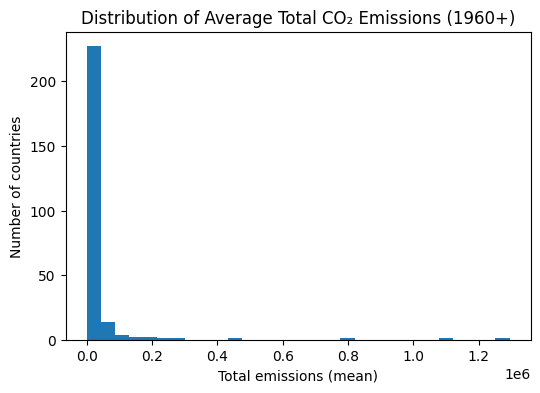

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(country_features['total_mean'], bins=30)
plt.title("Distribution of Average Total CO₂ Emissions (1960+)")
plt.xlabel("Total emissions (mean)")
plt.ylabel("Number of countries")
plt.show()

> The grouped country-level dataset reveals substantial heterogeneity in long-term emission behavior.  
>
> While a small subset of countries exhibits consistently high emissions, many nations show moderate emissions with rapidly increasing growth rates.  
>
> Fuel composition further differentiates countries into coal-dominant, gas-dominant, and mixed-energy profiles. These distinctions are critical for forming meaningful clusters in the next stage of analysis.

#**4) Modeling**


## Modeling

In this step, we use clustering techniques to group countries based on both **emission behaviors** and **economic characteristics**.

### - Feature Preparation
We used country-level summary statistics: means, max, std, per capita emissions, GDP, growth rates, and fuel mix ratios. Features were standardized for fair comparison.

### - Choosing Cluster Number
To find the optimal number of clusters for K-Means:
- **Elbow Method** suggests K = 4
- **Silhouette Score** is highest at K = 4  
So, we proceed with K = 4 clusters.

### - K-Means Clustering
Countries are grouped into 4 clusters based on their features.

**Cluster descriptions:**
- **C0**: Low-emission, small/developing countries  
- **C1**: China (high growth and emissions)  
- **C2**: USA, Russia – large industrial emitters  
- **C3**: Developed countries with moderate levels

### - Model Comparison
We also tested:
- **DBSCAN** (density-based)
- **GMM** (probabilistic)

 **KMeans performed best** and was selected.

### - Cluster Profiling
We analyzed average features per cluster to understand:
- Emission levels
- Fuel composition
- Growth trends
- Economic differences


In [ ]:
country_features.isna().sum()

,0
Nation,0
total_mean,0
total_std,1
total_max,0
percapita_mean,0
percapita_max,0
solid_mean,0
liquid_mean,0
gas_mean,0
cement_mean,0


In [ ]:
country_features['total_std'] = country_features['total_std'].fillna(0)

In [ ]:
#prepare X
X = country_features.drop(columns=['Nation'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

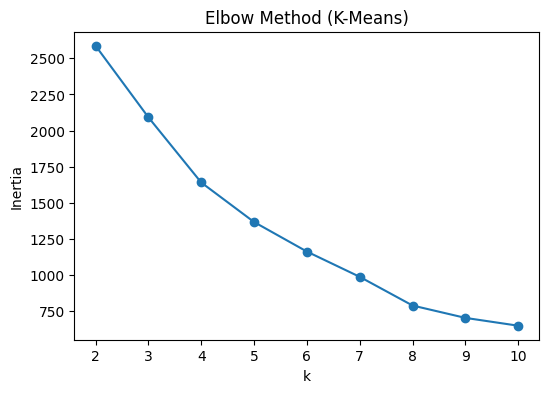

In [ ]:
# Choose K
# Elbow method (How many clusters explain most of the variance?)

inertia = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(K), inertia, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method (K-Means)")
plt.show()

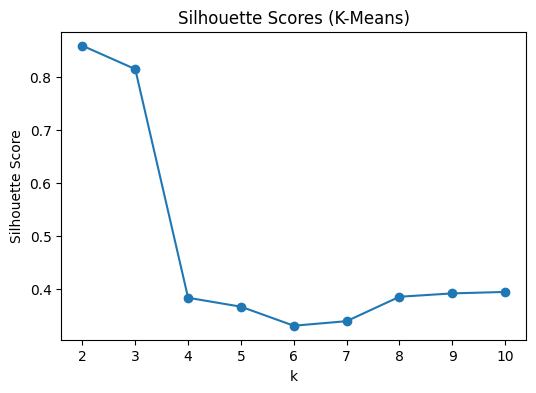

In [ ]:
# Silhouette score (How clean and separated are the clusters?)
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores (K-Means)")
plt.show()

In [ ]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
country_features['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

In [ ]:
country_features['cluster_kmeans'].value_counts().sort_index()

,count
cluster_kmeans,
0,174
1,1
2,3
3,77


In [ ]:
for c in sorted(country_features['cluster_kmeans'].unique()):
    print(f"\nCluster {c} examples:")
    display(country_features[country_features['cluster_kmeans']==c][['Nation']].head(10))



Cluster 0 examples:


,Nation
0,Afghanistan
1,Albania
3,American Samoa
4,Andorra
5,Angola
6,Anguilla
8,Antigua and Barbuda
9,Argentina
10,Armenia
11,Aruba



Cluster 1 examples:


,Nation
43,China



Cluster 2 examples:


,Nation
186,Russian Federation
237,Union of Soviet Socialist Republics [former]
241,United States



Cluster 3 examples:


,Nation
2,Algeria
7,Antarctic Fisheries
12,Australia
13,Austria
16,Bahrain
19,Belarus
20,Belgium
27,Bosnia and Herzegovina
31,Brunei Darussalam
32,Bulgaria


In [ ]:
cluster_profile = country_features.groupby('cluster_kmeans').mean(numeric_only=True)
cluster_profile

,total_mean,total_std,total_max,percapita_mean,percapita_max,solid_mean,liquid_mean,gas_mean,cement_mean,gas_flaring_mean,bunker_mean,aviation_mean,growth_rate,solid_ratio,liquid_ratio,gas_ratio
cluster_kmeans,,,,,,,,,,,,,,,,
0,2.681708e+03,1431.122161,5.722747e+03,0.798375,1.397225,300.952919,1741.683800,487.196578,141.242216,126.931734,179.695276,61.017039,74.919626,0.085733,0.754064,0.160202
1,1.085349e+06,969639.086671,3.148891e+06,0.856967,2.208046,827645.904762,154563.841270,34285.650794,68529.396825,1027.620073,4057.031746,1533.587302,49250.662586,0.814215,0.152056,0.033729
2,8.457970e+05,154041.846864,1.073629e+06,3.726177,4.525209,292673.002080,310214.644340,228149.253542,9982.744021,4947.184995,13374.181340,6279.789272,10926.973989,0.348423,0.338067,0.313509
3,4.206369e+04,15774.346692,7.284164e+04,2.634981,4.902980,16605.270684,16930.978532,8066.467479,1168.112463,1288.463429,1732.193836,620.527265,593.037700,0.403703,0.358964,0.237334


In [ ]:
results = []

# 1) K-Means
km = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km = km.fit_predict(X_scaled)
results.append(("KMeans", len(set(labels_km)), silhouette_score(X_scaled, labels_km)))

# 2) Hierarchical
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_hc = hc.fit_predict(X_scaled)
results.append(("Hierarchical(Ward)", len(set(labels_hc)), silhouette_score(X_scaled, labels_hc)))

# 3) DBSCAN
db = DBSCAN(eps=1.2, min_samples=5)
labels_db = db.fit_predict(X_scaled)

# DBSCAN
mask = labels_db != -1
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)

if n_clusters_db >= 2 and mask.sum() > 1:
    sil_db = silhouette_score(X_scaled[mask], labels_db[mask])
else:
    sil_db = np.nan

results.append(("DBSCAN", n_clusters_db, sil_db))

# 4) GMM
gmm = GaussianMixture(n_components=4, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)
results.append(("GMM(4)", len(set(labels_gmm)), silhouette_score(X_scaled, labels_gmm)))

results_df = pd.DataFrame(results, columns=["Model", "#Clusters", "Silhouette"])
results_df

,Model,#Clusters,Silhouette
0,KMeans,4,0.382767
1,Hierarchical(Ward),4,0.236920
2,DBSCAN,1,NaN
3,GMM(4),4,0.124474


In [ ]:
country_features['Cluster'] = country_features['cluster_kmeans']


In [ ]:
cluster_summary = (
    country_features
    .groupby('Cluster')
    .mean(numeric_only=True)
)

cluster_summary

,total_mean,total_std,total_max,percapita_mean,percapita_max,solid_mean,liquid_mean,gas_mean,cement_mean,gas_flaring_mean,bunker_mean,aviation_mean,growth_rate,solid_ratio,liquid_ratio,gas_ratio,cluster_kmeans
Cluster,,,,,,,,,,,,,,,,,
0,2.681708e+03,1431.122161,5.722747e+03,0.798375,1.397225,300.952919,1741.683800,487.196578,141.242216,126.931734,179.695276,61.017039,74.919626,0.085733,0.754064,0.160202,0.0
1,1.085349e+06,969639.086671,3.148891e+06,0.856967,2.208046,827645.904762,154563.841270,34285.650794,68529.396825,1027.620073,4057.031746,1533.587302,49250.662586,0.814215,0.152056,0.033729,1.0
2,8.457970e+05,154041.846864,1.073629e+06,3.726177,4.525209,292673.002080,310214.644340,228149.253542,9982.744021,4947.184995,13374.181340,6279.789272,10926.973989,0.348423,0.338067,0.313509,2.0
3,4.206369e+04,15774.346692,7.284164e+04,2.634981,4.902980,16605.270684,16930.978532,8066.467479,1168.112463,1288.463429,1732.193836,620.527265,593.037700,0.403703,0.358964,0.237334,3.0


In [ ]:
for c in sorted(country_features['Cluster'].unique()):
    print(f"\nCluster {c}:")
    display(
        country_features[country_features['Cluster']==c]
        [['Nation']]
        .head(10)
    )


Cluster 0:


,Nation
0,Afghanistan
1,Albania
3,American Samoa
4,Andorra
5,Angola
6,Anguilla
8,Antigua and Barbuda
9,Argentina
10,Armenia
11,Aruba



Cluster 1:


,Nation
43,China



Cluster 2:


,Nation
186,Russian Federation
237,Union of Soviet Socialist Republics [former]
241,United States



Cluster 3:


,Nation
2,Algeria
7,Antarctic Fisheries
12,Australia
13,Austria
16,Bahrain
19,Belarus
20,Belgium
27,Bosnia and Herzegovina
31,Brunei Darussalam
32,Bulgaria


In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Data Loading From (Gross domestic product (GDP))**

In [ ]:
#Data loading
file_path = "/content/drive/MyDrive/MSAI_Pro_L1/PTAI_Project/gdp-worldbank.csv"
gdp = pd.read_csv(file_path)
gdp.head()
gdp.columns


Index(['Entity', 'Code', 'Year', 'GDP, PPP (constant 2021 international $)'], dtype='object')

# **Clean up missing GDP data and fill in missing information**

**1- Initial Inspection**

In [ ]:
#1.1)Initial Inspection
print(gdp.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7236 entries, 0 to 7235
Data columns (total 4 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   Entity                                    7236 non-null   object
 1   Code                                      6816 non-null   object
 2   Year                                      7236 non-null   int64 
 3   GDP, PPP (constant 2021 international $)  7236 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 226.3+ KB
None


In [ ]:
#2.1)Missing Values
gdp.isna().sum()

,0
Entity,0
Code,420
Year,0
"GDP, PPP (constant 2021 international $)",0


**2-Select the important columns**

In [ ]:
#Select only the important columns: Country, Year, GDP
gdp = gdp[['Entity', 'Year', 'GDP, PPP (constant 2021 international $)']].copy()


**3-Unifying column names**

In [ ]:
#Rename to Make sure that the country and year columns have the same format in the emissions dataset.
gdp = gdp.rename(columns={
    'Entity': 'Nation',
    'year': 'Year',
    'GDP, PPP (constant 2021 international $)': 'GDP'
})

#Confirming the year type
gdp['Year'] = gdp['Year'].astype(int)
df_imputed['Year'] = df_imputed['Year'].astype(int)

**4-Cleaning up illogical values**

In [ ]:
#4.1) Delete invalid GDP
gdp= gdp[gdp['GDP'] > 0].copy()


In [ ]:
#4.2) Species Confirmation
gdp['Year'] = gdp['Year'].astype(int)
gdp['GDP'] = gdp['GDP'].astype(float)


**5-Country Name Alignment**

In [ ]:
# Country name alignment dictionary (GDP ↔ Emissions)
country_map = {
    # America
    'United States': 'United States',

    # South America
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'Bolivia (Plurinational State of)': 'Bolivia',

    # Asia
    'Türkiye': 'Turkey',
    "Lao People's Democratic Republic": 'Laos',
    'Syrian Arab Republic': 'Syria',
    'Republic of Korea': 'South Korea',
    "Democratic People's Republic of Korea": 'North Korea',
    'Brunei Darussalam': 'Brunei',
    'Malaysia (Peninsular)': 'Malaysia',
    'Malaysia, Sabah': 'Malaysia',
    'Malaysia, Sarawak': 'Malaysia',
    'Timor-Leste': 'Timor',

    # Africa
    'United Republic of Tanzania': 'Tanzania',
    'Democratic Republic of the Congo': 'Congo, Dem. Rep.',

    # Europe
    'Republic of Moldova': 'Moldova',
    'Germany, Federal Republic of': 'Germany',
    'France incl. Monaco': 'France',
    'Italy and San Marino': 'Italy',
    'Netherlands, Kingdom of the': 'Netherlands',

    # China regions
    'China, Hong Kong Special Administrative Region': 'Hong Kong',
    'China, Macao Special Administrative Region': 'Macao',
}


In [ ]:
#Country Name Alignment
gdp.loc[:, 'Nation'] = gdp['Nation'].replace(country_map)

**6-Removal of inappropriate entities**

In [ ]:
#6.1)Historical States
gdp= gdp.loc[
    ~gdp['Nation'].isin(historical)
].copy()


NameError: name 'historical' is not defined

In [ ]:
#6.2) Territories / Colonies
gdp= gdp.loc[
    ~gdp['Nation'].isin(territories)
].copy()


**7-Validation**

In [ ]:
#7.1) Number of countries
gdp['Nation'].nunique()


212

In [ ]:
#7.2)Time coverage
gdp['Year'].min(), gdp['Year'].max()


(1990, 2024)

In [ ]:
#7.3) Sample Test
gdp.sample(10)


,Nation,Year,GDP
6442,Tanzania,2003,7.421697e+10
1560,Curacao,2015,4.875471e+09
5313,Qatar,1993,3.403966e+10
5120,Paraguay,2010,7.309358e+10
3092,Ireland,2016,3.857690e+11
97,Andorra,1993,2.695745e+09
7163,World,2022,1.620575e+14
940,Bulgaria,1998,1.071008e+11
3936,Malawi,2004,1.510364e+10
6978,Upper-middle-income countries,2012,3.739068e+13


**8-Critical Check**

In [ ]:
em_countries = set(df_imputed['Nation'].unique())
gdp_countries = set(gdp['Nation'].unique())

print("In emissions only:", len(em_countries - gdp_countries))
print("In GDP only:", len(gdp_countries - em_countries))


In emissions only: 85
In GDP only: 42


**9-Save the clean copy**

In [ ]:
gdp.to_csv("gdp_clean.csv", index=False)


# **Merge by Link: Emissions (Nation, Year) with GDP (Nation, Year)**

In [ ]:
#Merge Two datasets
df_merged = pd.merge(
    df_imputed,
    gdp,
    on=['Nation', 'Year'],
    how='left'
)

In [ ]:
#Check the merge result
#1)Column Inspection
df_merged.columns

Index(['Nation', 'Nation ID', 'Year', 'Total', 'Solid_fuel', 'Liquid_fuel',
       'Gas_fuel', 'Cement', 'Gas_flaring', 'Per_capita', 'Bunker_fuel',
       'Aviation_fuel', 'MissingCount', 'GDP'],
      dtype='object')

In [ ]:
#2)Checking missing values
df_merged.isna().sum()


,0
Nation,0
Nation ID,0
Year,0
Total,0
Solid_fuel,0
Liquid_fuel,0
Gas_fuel,0
Cement,0
Gas_flaring,0
Per_capita,0


# **Spot Check**

In [ ]:
df_merged[['Nation','Year','Total','GDP']].sample(10)

,Nation,Year,Total,GDP
7467,Mauritania,2019,1373.0,2.753096e+10
1323,Bolivia (Plurinational State of),1967,516.0,NaN
5490,Hungary,2003,16002.0,2.558307e+11
6189,Jordan,1988,2540.0,NaN
1132,Belize,2018,181.0,4.367581e+09
9198,Peru,1987,7031.0,NaN
8651,Norway including Svalbard and Jan Mayen Islands,1961,3641.0,NaN
98,Albania,1995,564.0,1.642060e+10
5485,Hungary,1998,16048.0,2.098321e+11
2044,Cameroon,2020,2683.0,1.248535e+11


In [ ]:
#Special cleaning for analysis only
df_analysis_clean = df_merged.dropna(subset=['GDP']).copy()


# **analysis**

In [ ]:
#1) Track One: GDP within the Clusters
df_analysis_clean.merge(
    country_features[['Nation','Cluster']],
    on='Nation'
).groupby('Cluster')['GDP'].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,3698.0,1.224652e+11,3.398244e+11,2.625574e+07,5.196203e+09,2.597925e+10,9.154689e+10,3.902035e+12
1,33.0,1.219785e+13,9.088027e+12,1.892271e+12,4.388459e+12,9.251999e+12,1.916294e+13,3.036089e+13
2,33.0,1.734207e+13,3.889580e+12,1.106590e+13,1.423955e+13,1.801208e+13,2.011923e+13,2.427613e+13
3,1645.0,7.814473e+11,1.347858e+12,5.270796e+08,6.559496e+10,2.933059e+11,7.498014e+11,1.225065e+13


# Economic-Environmental Relationships
This section examines the relationships between the merged CO₂ emissions and GDP datasets. We analyze how economic output correlates with emissions patterns across five key dimensions to reveal underlying connections between economic development and environmental impact.


# Relationship 1: Per Capita Emissions vs GDP
GDP data were combined with emissions data using country and year as common keys, keeping emissions data complete, and using GDP data for analytical purposes only.


In [ ]:
#2) Track Two:The relationship between GDP and emissions
df_analysis_clean[['GDP','Total','Per_capita']].corr()

,GDP,Total,Per_capita
GDP,1.000000,0.930025,0.148548
Total,0.930025,1.000000,0.138901
Per_capita,0.148548,0.138901,1.000000


In [ ]:
#Merge Cluster with df_analysis_clean
df_analysis_clean = df_analysis_clean.merge(
    country_features[['Nation', 'cluster_kmeans']],
    on='Nation',
    how='left'
)
# Renaming to make drawing easier
df_analysis_clean = df_analysis_clean.rename(columns={'cluster_kmeans':'Cluster'})


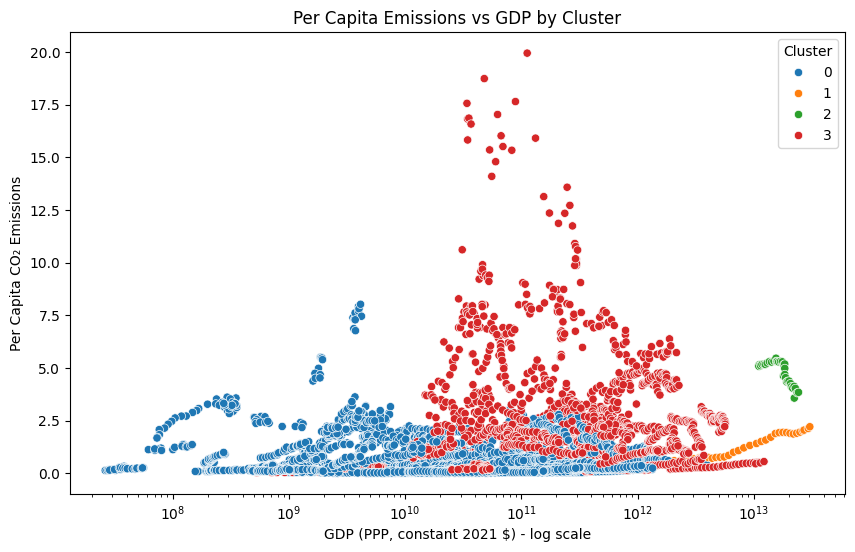

In [ ]:

#Draw a scatterplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_analysis_clean,
    x='GDP',
    y='Per_capita',
    hue='Cluster',   # الآن موجود
    palette='tab10'
)
plt.xscale('log')  # GDP غالبًا يكون متدرجًا لوجاريتمي
plt.title("Per Capita Emissions vs GDP by Cluster")
plt.xlabel("GDP (PPP, constant 2021 $) - log scale")
plt.ylabel("Per Capita CO₂ Emissions")
plt.legend(title="Cluster")
plt.show()


# Relationship 2: Emissions Intensity (Emissions per GDP)
- Which countries emit more CO₂ per unit of GDP?

In [ ]:
# Emission intensity = Total emissions / GDP
df_analysis_clean['emission_intensity'] = (
    df_analysis_clean['Total'] / df_analysis_clean['GDP']
)

# Average intensity per cluster
intensity_by_cluster = (
    df_analysis_clean
    .groupby('Cluster')['emission_intensity']
    .mean()
)

intensity_by_cluster


,emission_intensity
Cluster,
0,4.401809e-08
1,1.873599e-07
2,8.703667e-08
3,9.424621e-08


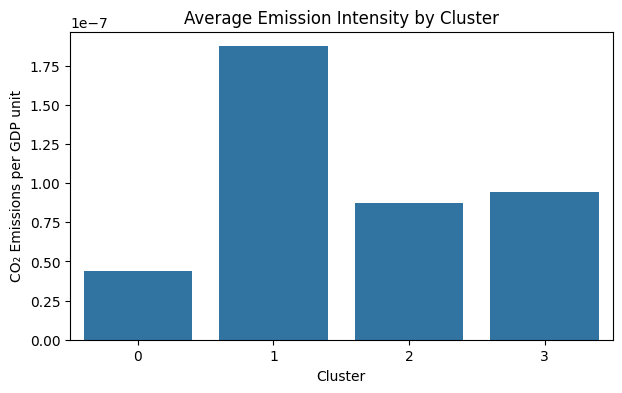

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(
    x=intensity_by_cluster.index,
    y=intensity_by_cluster.values
)
plt.title("Average Emission Intensity by Cluster")
plt.xlabel("Cluster")
plt.ylabel("CO₂ Emissions per GDP unit")
plt.show()


# Relationship 3: GDP Growth vs Emissions Growth
- Does economic growth come with increasing emissions?

In [ ]:
# GDP growth rate per country
def gdp_growth(group):
    x = np.arange(len(group))
    y = group['GDP'].values
    return np.polyfit(x, y, 1)[0] if len(y) > 1 else 0

gdp_growth_rate = (
    df_analysis_clean
    .groupby('Nation')
    .apply(gdp_growth)
)

# Combine with emission growth
growth_df = country_features[['Nation', 'growth_rate']].copy()
growth_df['gdp_growth'] = growth_df['Nation'].map(gdp_growth_rate)

growth_df.dropna(inplace=True)
growth_df.head()


/tmp/ipython-input-2174286382.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(gdp_growth)


,Nation,growth_rate,gdp_growth
0,Afghanistan,37.611655,3.671633e+09
1,Albania,2.615543,1.101666e+09
2,Algeria,712.063364,1.376424e+10
4,Andorra,0.179144,7.306488e+07
5,Angola,135.188892,8.025672e+09


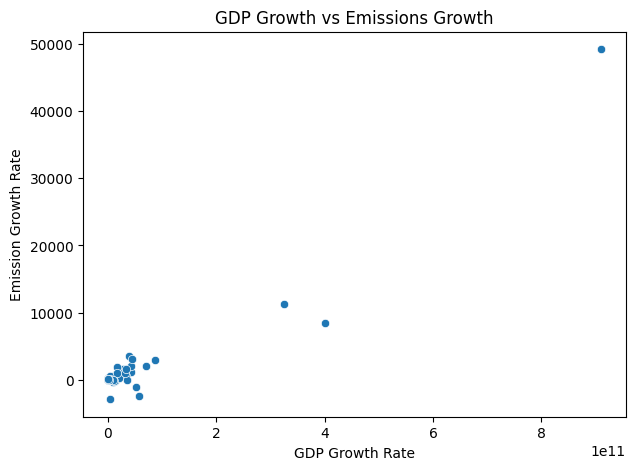

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=growth_df,
    x='gdp_growth',
    y='growth_rate'
)
plt.title("GDP Growth vs Emissions Growth")
plt.xlabel("GDP Growth Rate")
plt.ylabel("Emission Growth Rate")
plt.show()


# Relationship 4: Fuel Mix vs GDP
- Do richer countries rely more on cleaner fuels?

In [ ]:
# Create fuel_gdp dataframe with fuel ratios
fuel_gdp = df_analysis_clean.groupby('Nation').agg({
    'GDP': 'mean',
    'Solid_fuel': 'mean',
    'Liquid_fuel': 'mean',
    'Gas_fuel': 'mean',
    'Total': 'mean'
}).reset_index()

# Calculate fuel ratios
fuel_gdp['solid_ratio'] = fuel_gdp['Solid_fuel'] / fuel_gdp['Total']
fuel_gdp['liquid_ratio'] = fuel_gdp['Liquid_fuel'] / fuel_gdp['Total']
fuel_gdp['gas_ratio'] = fuel_gdp['Gas_fuel'] / fuel_gdp['Total']

# Remove any infinite or NaN values
fuel_gdp = fuel_gdp.replace([np.inf, -np.inf], np.nan).dropna()

fuel_gdp.head()


# Select needed columns
fuel_plot = fuel_gdp[['GDP', 'solid_ratio', 'liquid_ratio', 'gas_ratio']].copy()

# Convert to long format
fuel_plot_long = fuel_plot.melt(
    id_vars='GDP',
    var_name='Fuel_Type',
    value_name='Ratio'
)

fuel_plot_long.head()

,GDP,Fuel_Type,Ratio
0,7.441025e+10,solid_ratio,0.289082
1,2.851868e+10,solid_ratio,0.117851
2,4.655411e+11,solid_ratio,0.015068
3,4.112362e+09,solid_ratio,0.000000
4,1.730008e+11,solid_ratio,0.373993


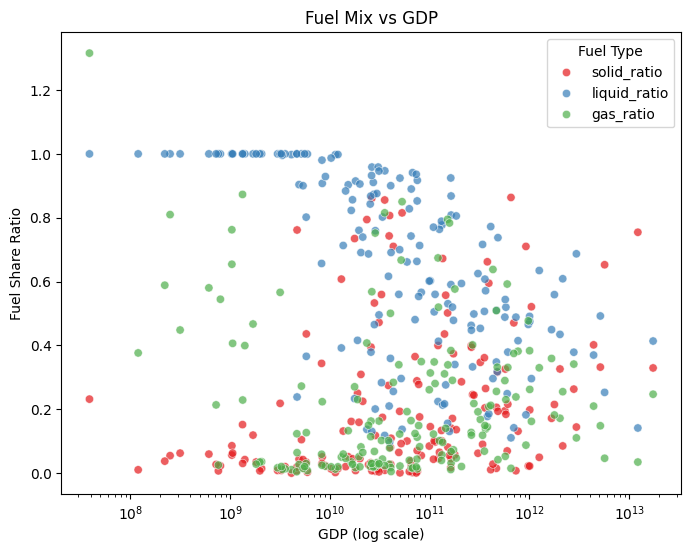

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=fuel_plot_long,
    x='GDP',
    y='Ratio',
    hue='Fuel_Type',
    palette='Set1',
    alpha=0.7
)

plt.xscale('log')
plt.title("Fuel Mix vs GDP")
plt.xlabel("GDP (log scale)")
plt.ylabel("Fuel Share Ratio")
plt.legend(title="Fuel Type")
plt.grid(False)
plt.show()

# Relationship 5: International Transport Emissions vs GDP
- How does a country’s GDP influence its international transport CO₂ emissions?

In [ ]:
# Create trade_df dataframe with international transport emissions
trade_df = df_analysis_clean.groupby('Nation').agg({
    'GDP': 'mean',
    'Bunker_fuel': 'mean',
    'Aviation_fuel': 'mean'
}).reset_index()

# Rename columns for clarity
trade_df = trade_df.rename(columns={
    'Bunker_fuel': 'bunker_mean',
    'Aviation_fuel': 'aviation_mean'
})

# Remove any NaN values
trade_df = trade_df.dropna()

trade_df.head()


# Select needed columns
trade_plot = trade_df[['GDP', 'aviation_mean', 'bunker_mean']].copy()

# Convert to long format
trade_plot_long = trade_plot.melt(
    id_vars='GDP',
    var_name='Transport_Type',
    value_name='Emissions'
)

trade_plot_long.head()


,GDP,Transport_Type,Emissions
0,7.441025e+10,aviation_mean,39.260870
1,2.851868e+10,aviation_mean,14.212121
2,4.655411e+11,aviation_mean,281.121212
3,4.112362e+09,aviation_mean,0.000000
4,1.730008e+11,aviation_mean,212.878788


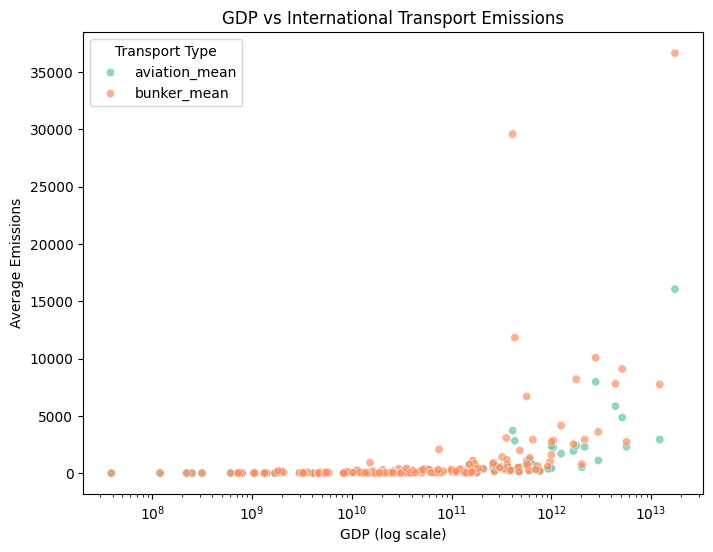

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=trade_plot_long,
    x='GDP',
    y='Emissions',
    hue='Transport_Type',
    palette='Set2',
    alpha=0.7
)

plt.xscale('log')
plt.title("GDP vs International Transport Emissions")
plt.xlabel("GDP (log scale)")
plt.ylabel("Average Emissions")
plt.legend(title="Transport Type")
plt.grid(False)
plt.show()
